# Premier League 2024-25: Transfer Window Analysis

You have just joined the analytics team at a Premier League club. The transfer window opens in two weeks and the recruitment team is counting on you to help them make data-driven decisions.

Your job today: dig into the 2024-25 season stats and answer some real questions about players.

The data is real. It covers every player from the 2024-25 Fantasy Premier League season and loads straight from the internet, so there is nothing to download.

Let's get into it.

---

## Before we start: setting up the project

When you start a new Python project, you need two things: a way to manage your libraries, and a way to track your work. We use **uv** for libraries and **git** for tracking.

### What is uv?

uv is a Python package manager. It installs libraries and creates an isolated environment for your project so the libraries here do not interfere with anything else on your machine. Think of it like pip, but faster and it handles everything automatically.

### Setting up a new project

Open your terminal and run:

```bash
mkdir pl-analysis
cd pl-analysis
uv init
uv add notebook pandas numpy matplotlib seaborn scipy
```

`uv init` creates the project structure. `uv add` installs the libraries you need.

### Open Jupyter and create your notebook

```bash
uv run jupyter notebook
```

This opens Jupyter in your browser. Create a new notebook, name it something sensible like `analysis.ipynb`, and you are ready to go.

### What did uv create?

```
.venv/           -- your isolated environment -- do NOT track in git
.python-version  -- which Python version this project uses
pyproject.toml   -- lists your dependencies
uv.lock          -- locks exact versions of every package
.gitignore       -- already has .venv/ in it
```

If someone else clones your repo, they just run `uv sync` and get the exact same environment. That is what `pyproject.toml` and `uv.lock` are for.

One more thing to add to `.gitignore` -- Jupyter's auto-save folder:

```bash
echo ".ipynb_checkpoints/" >> .gitignore
```

### Your first commit

Now before writing a single line of analysis:

```bash
git add .
git commit -m "Initial project setup"
```

From here, every time you finish a meaningful piece of work -- loaded the data, added filtering, built the visualisation -- make a commit. By the end of the session your git history will tell the story of your analysis.

### Setup new folder

```bash
mkdir pl-analysis

cd pl-analysis

uv init

uv add jupyter pandas numpy matplotlib seaborn scipy
```

## Step 0: Set up version control

Before writing a single line of analysis, you set up git. Why? Because analysis breaks. Files get overwritten. Notebooks crash. Version control means you can always get back to a working state.

Every project starts here. Open your terminal and run:

```bash
git init
git add .
git commit -m "Start transfer window analysis"
```

The order matters and it never changes:

1. `git add` -- tell git which files to include in the next snapshot
2. `git commit` -- take the snapshot
3. `git push` -- send it to GitHub

You cannot commit without adding first. You cannot push without committing first.

---

## Step 1: Load the data and have a look around

Let's bring the dataset in and get a feel for what we are working with.

In [21]:
import pandas as pd
import numpy as np

URL = 'https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/2024-25/cleaned_players.csv'
data = pd.read_csv(URL)

print(data.shape)
data.head()

(804, 19)


,first_name,second_name,goals_scored,assists,total_points,minutes,goals_conceded,creativity,influence,threat,bonus,bps,ict_index,clean_sheets,red_cards,yellow_cards,selected_by_percent,now_cost,element_type
0,Fábio,Ferreira Vieira,0,0,0,0,0,0.0,0.0,0.0,0,0,0.0,0,0,0,0.0,54,MID
1,Gabriel,Fernando de Jesus,3,2,42,600,5,119.5,154.4,255.0,6,152,52.6,2,0,4,1.0,65,FWD
2,Gabriel,dos Santos Magalhães,3,2,117,2363,22,208.8,584.6,287.0,9,459,108.2,10,0,4,12.2,61,DEF
3,Kai,Havertz,9,3,97,1872,20,269.0,467.6,711.0,14,343,144.8,7,0,5,6.2,77,FWD
4,Karl,Hein,0,0,0,0,0,0.0,0.0,0.0,0,0,0.0,0,0,0,0.0,40,GK


`data.shape` tells you how many rows and columns you have. Always worth checking first.

Now let's look at the column types.

Before we run this next cell, something worth knowing: pandas uses the word `object` to describe text columns. So if you see `object` in the output, it just means that column contains strings. It is not an error, it is just pandas' way of saying "this is text".

In [22]:
data.dtypes

first_name              object
second_name             object
goals_scored             int64
assists                  int64
total_points             int64
minutes                  int64
goals_conceded           int64
creativity             float64
influence              float64
threat                 float64
bonus                    int64
bps                      int64
ict_index              float64
clean_sheets             int64
red_cards                int64
yellow_cards             int64
selected_by_percent    float64
now_cost                 int64
element_type            object
dtype: object

### Discovering something odd

Let's check what positions are in the dataset.

In [23]:
data['element_type'].unique()

array(['MID', 'FWD', 'DEF', 'GK', 'AM'], dtype=object)

You will notice something unexpected: there is an `AM` value alongside GK, DEF, MID, FWD. What is that?

Let's investigate before doing anything with it.

In [24]:
# Let's look at some AM rows and see what they look like
data[data['element_type'] == 'AM'][['first_name', 'second_name', 'element_type', 'goals_scored', 'assists', 'minutes']].head(10)

,first_name,second_name,element_type,goals_scored,assists,minutes
32,Mikel,Arteta,AM,0,0,0
79,Unai,Emery,AM,0,0,0
121,Andoni,Iraola,AM,0,0,0
157,Thomas,Frank,AM,0,0,0
208,Fabian,Hürzeler,AM,0,0,0
256,Enzo,Maresca,AM,0,0,0
297,Oliver,Glasner,AM,0,0,0
330,David,Moyes,AM,0,0,0
364,Marco Alexandre,Saraiva da Silva,AM,0,0,0
402,Kieran,McKenna,AM,0,0,0


Look at the names: Mikel Arteta, Pep Guardiola, Arne Slot, Thomas Frank. These are all managers.

FPL introduced manager cards in 2024-25 where you could pick a real manager for your squad. They have 0 goals, 0 assists, 0 minutes. They are not players and we do not want them in our analysis.

Now that we know what AM means, let's filter them out.

In [25]:
data = data[data['element_type'] != 'AM']

print(f"Players remaining: {len(data)}")
print(data['element_type'].unique())

Players remaining: 784
['MID' 'FWD' 'DEF' 'GK']


Good. Now let's rename the columns we will use most so the rest of the notebook is easier to read.

In [26]:
data = data.rename(columns={
    'element_type': 'Position',
    'goals_scored': 'Goals',
    'now_cost':     'Cost',
    'total_points': 'Points',
})

data.head()

,first_name,second_name,Goals,assists,Points,minutes,goals_conceded,creativity,influence,threat,bonus,bps,ict_index,clean_sheets,red_cards,yellow_cards,selected_by_percent,Cost,Position
0,Fábio,Ferreira Vieira,0,0,0,0,0,0.0,0.0,0.0,0,0,0.0,0,0,0,0.0,54,MID
1,Gabriel,Fernando de Jesus,3,2,42,600,5,119.5,154.4,255.0,6,152,52.6,2,0,4,1.0,65,FWD
2,Gabriel,dos Santos Magalhães,3,2,117,2363,22,208.8,584.6,287.0,9,459,108.2,10,0,4,12.2,61,DEF
3,Kai,Havertz,9,3,97,1872,20,269.0,467.6,711.0,14,343,144.8,7,0,5,6.2,77,FWD
4,Karl,Hein,0,0,0,0,0,0.0,0.0,0.0,0,0,0.0,0,0,0,0.0,40,GK


In [27]:
data[['Goals', 'assists', 'minutes', 'yellow_cards', 'Points']].describe().round(2)

,Goals,assists,minutes,yellow_cards,Points
count,784.00,784.00,784.00,784.00,784.00
mean,1.38,1.25,954.70,1.97,39.91
std,3.14,2.34,1074.59,2.64,48.84
min,0.00,0.00,0.00,0.00,-1.00
25%,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,477.50,1.00,19.50
75%,1.00,2.00,1792.25,3.00,65.00
max,29.00,18.00,3420.00,12.00,344.00


That's our dataset ready. Now let's actually use it.

---

## Step 2: Clean the player names

The raw data has `first_name` and `second_name` in separate columns. We need one column with the full name for reports and lookups.

While we are here, let's understand how strings actually work in Python.

### Combining strings

You can stick strings together using `+`. Let's try it:

In [28]:
first = 'Mohamed'
last  = 'Salah'

full = first + ' ' + last
print(full)

Mohamed Salah


Simple. Now let's do it across the whole dataset.

In [29]:
data['Player'] = data['first_name'] + ' ' + data['second_name']

data[['Player', 'Position', 'Goals', 'assists']].head()

,Player,Position,Goals,assists
0,Fábio Ferreira Vieira,MID,0,0
1,Gabriel Fernando de Jesus,FWD,3,2
2,Gabriel dos Santos Magalhães,DEF,3,2
3,Kai Havertz,FWD,9,3
4,Karl Hein,GK,0,0


### Strings cannot be changed once created

This is one of the most important things to understand about strings in Python. Once a string exists, you cannot modify it. You can only create a new one.

Try this:

In [30]:
name = 'Erling Haaland'

# Try uncommenting the line below and running it -- see what error you get
# name[0] = 'e'

# What you do instead: build a new string from parts
lowercase_start = 'e' + name[1:]
print(lowercase_start)
print(name)   # the original is completely untouched

erling Haaland
Erling Haaland


Any method you call on a string -- `.lower()`, `.strip()`, `.replace()` -- gives you back a new string. If you do not save it to a variable, the result is gone.

### Splitting strings

`.split()` breaks a string apart at a separator and gives you a list back.

In [31]:
# A scouting report that came in as a formatted string
report = 'Salah:29 goals:18 assists:MID'

# Without maxsplit -- splits on every colon
print(report.split(':'))

# With maxsplit=1 -- stops after the first split
# useful when you want just the player name and the rest as one chunk
print(report.split(':', maxsplit=1))

['Salah', '29 goals', '18 assists', 'MID']
['Salah', '29 goals:18 assists:MID']


`maxsplit` is useful when your separator appears more than once but you only want to cut at the first one. Here we pull the player name off the front and keep everything else intact.

---

## Step 3: Lists and tuples

Two data structures you will use constantly. Let's understand both properly.

### Nested lists

A nested list is a list that contains other lists. You have probably seen this already without realising -- when we select multiple columns from a DataFrame we use double brackets. More on that shortly.

First let's understand the indexing. You drill down layer by layer, one set of square brackets at a time.

In [32]:
# A shortlist of top scorers this season
players = [
    ['Mohamed Salah', 29],
    ['Erling Haaland', 22],
    ['Bryan Mbeumo', 20]
]

# The whole list
print(players)

[['Mohamed Salah', 29], ['Erling Haaland', 22], ['Bryan Mbeumo', 20]]


In [88]:
players

[['Mohamed Salah', 29], ['Erling Haaland', 22], ['Bryan Mbeumo', 20]]

In [33]:
# First player -- one set of brackets
print(players[0])

['Mohamed Salah', 29]


In [34]:
# First player's name -- drill one level deeper
print(players[0][0])

Mohamed Salah


In [35]:
# First player's goals
print(players[0][1])

29


In [36]:
# Second player's name
print(players[1][0])

Erling Haaland


Each set of brackets takes you one level deeper. Work through it step by step and it always makes sense.

### You have already seen this in pandas

When we select multiple columns from a DataFrame we write:

```python
data[['Player', 'Goals', 'assists']]
```

Those double brackets are not special syntax. The outer brackets are the indexing. The inner brackets are a list of column names. You are passing a list into the indexing operator -- same idea as nested lists.

In [37]:
# Single column -- one set of brackets, gives you one column
data['Goals'].head()

0    0
1    3
2    3
3    9
4    0
Name: Goals, dtype: int64

In [38]:
# Multiple columns -- the inner brackets are a list of names
columns = ['Player', 'Goals', 'assists']
data[columns].head()

,Player,Goals,assists
0,Fábio Ferreira Vieira,0,0
1,Gabriel Fernando de Jesus,3,2
2,Gabriel dos Santos Magalhães,3,2
3,Kai Havertz,9,3
4,Karl Hein,0,0


In [39]:
# Same thing written directly
data[['Player', 'Goals', 'assists']].head()

,Player,Goals,assists
0,Fábio Ferreira Vieira,0,0
1,Gabriel Fernando de Jesus,3,2
2,Gabriel dos Santos Magalhães,3,2
3,Kai Havertz,9,3
4,Karl Hein,0,0


### Tuples

Tuples look like lists but use round brackets. The key difference: you cannot change them after creating them.

That makes them the right choice for records that should stay fixed -- a player snapshot, a coordinate, a database row.

In [40]:
player_record = ('Mohamed Salah', 'MID', 29)

print(player_record)
print(player_record[0])

# Try uncommenting this and see what error you get
# player_record[2] = 30

('Mohamed Salah', 'MID', 29)
Mohamed Salah


In [41]:
# To produce an updated version, build a new tuple
updated_record = player_record[:2] + (30,)
print(f"Original: {player_record}")
print(f"Updated:  {updated_record}")

Original: ('Mohamed Salah', 'MID', 29)
Updated:  ('Mohamed Salah', 'MID', 30)


Lists are mutable -- you can change, add, and remove items freely. Tuples are immutable -- once created, that's it. Use tuples when the data should not change.

---

## Step 4: List comprehensions

A list comprehension is a shorter way to build a list. Instead of writing a for loop with `.append()`, you describe the list in one line.

Let's start with the long way so we understand what is happening:

In [42]:
# The long way -- a for loop
squares = []
for i in range(1, 6):
    squares.append(i ** 2)
print(squares)

[1, 4, 9, 16, 25]


In [43]:
# The list comprehension way -- same result, one line
squares = [i ** 2 for i in range(1, 6)]
print(squares)

[1, 4, 9, 16, 25]


The pattern is always:

```python
[expression for item in iterable]
```

You can also add a condition to filter:

In [44]:
# Only square the odd numbers -- range with a step of 2
odd_squares = [i ** 2 for i in range(1, 11, 2)]
print(odd_squares)

[1, 9, 25, 49, 81]


### Building a contribution score

**Is a goal worth more than an assist?**

Ronaldo would say yes -- goals win games. But look at Messi's career and you would argue an assist is just as valuable. There is no right answer.

For our analysis, we are going to say a goal is worth 2 points and an assist is worth 1. That is a choice we are making, not an official stat. You could change those weights and see how the rankings shift -- we will do exactly that when we get to functions.

For now let's calculate the contribution score for every player.

To do this across two columns at once, we need `zip`. Let's understand what it does first:

In [45]:
# zip pairs up two lists element by element
goals   = [29, 22, 20]
assists = [18, 3, 9]

for g, a in zip(goals, assists):
    print(f"Goals: {g}, Assists: {a}")

Goals: 29, Assists: 18
Goals: 22, Assists: 3
Goals: 20, Assists: 9


In [46]:
# Now use it in a list comprehension across the dataset
data['Contribution'] = [g * 2 + a for g, a in zip(data['Goals'], data['assists'])]

data[['Player', 'Goals', 'assists', 'Contribution']].sort_values('Contribution', ascending=False).head(10)

,Player,Goals,assists,Contribution
464,Mohamed Salah,29,18,76
574,Alexander Isak,23,6,52
135,Bryan Mbeumo,20,9,49
493,Erling Haaland,22,3,47
624,Chris Wood,20,3,43
146,Yoane Wissa,18,6,42
242,Cole Palmer,15,10,40
67,Ollie Watkins,16,8,40
767,Matheus Santos Carneiro Da Cunha,15,7,37
730,Jarrod Bowen,13,11,37


---

## Step 5: Filtering and sorting

This is where we start answering the recruitment team's actual questions.

### Sorting

`sort_values()` orders the rows. `ascending=False` puts the biggest values first.

In [47]:
data.sort_values(by='Goals', ascending=False)[['Player', 'Position', 'Goals', 'assists', 'Points']].head(10)

,Player,Position,Goals,assists,Points
464,Mohamed Salah,MID,29,18,344
574,Alexander Isak,FWD,23,6,211
493,Erling Haaland,FWD,22,3,181
624,Chris Wood,FWD,20,3,200
135,Bryan Mbeumo,MID,20,9,236
146,Yoane Wissa,FWD,18,6,185
67,Ollie Watkins,FWD,16,8,186
767,Matheus Santos Carneiro Da Cunha,FWD,15,7,178
242,Cole Palmer,MID,15,10,214
791,Jørgen Strand Larsen,FWD,14,4,145


### How filtering actually works

Before we filter, let's understand what is happening under the hood.

When you write a condition on a column, pandas checks every row and gives back True or False:

In [48]:
# This gives you True or False for every row
data['Goals'] > 15

0      False
1      False
2      False
3      False
4      False
       ...  
798    False
799    False
801    False
802    False
803    False
Name: Goals, Length: 784, dtype: bool

Now when you pass that into `data[...]`, pandas keeps only the rows where the value is True. That is all filtering is.

In [49]:
# Keep only the rows where Goals > 15
top_scorers = data[data['Goals'] > 15]
print(f"Found {len(top_scorers)} players")
top_scorers[['Player', 'Position', 'Goals']]

Found 7 players


,Player,Position,Goals
67,Ollie Watkins,FWD,16
135,Bryan Mbeumo,MID,20
146,Yoane Wissa,FWD,18
464,Mohamed Salah,MID,29
493,Erling Haaland,FWD,22
574,Alexander Isak,FWD,23
624,Chris Wood,FWD,20


### Filtering on two conditions

Combine conditions with `&` (and) or `|` (or). Each condition must be in its own brackets -- Python needs this to evaluate them in the right order.

In [50]:
# Goals above 10 AND assists above 5
all_rounders = data[(data['Goals'] > 10) & (data['assists'] > 5)]
print(f"Found {len(all_rounders)} players")
all_rounders[['Player', 'Position', 'Goals', 'assists']]

Found 12 players


,Player,Position,Goals,assists
67,Ollie Watkins,FWD,16,8
93,Justin Kluivert,MID,12,6
99,Antoine Semenyo,MID,11,7
135,Bryan Mbeumo,MID,20,9
146,Yoane Wissa,FWD,18,6
242,Cole Palmer,MID,15,10
463,Luis Díaz,MID,13,7
464,Mohamed Salah,MID,29,18
574,Alexander Isak,FWD,23,6
691,Brennan Johnson,MID,11,6


### Filter then aggregate

Filter to a subset, then calculate something on those rows. This pattern comes up constantly.

In [51]:
# Total minutes played by players with more than 5 yellow cards
total = data[data['yellow_cards'] > 5]['minutes'].sum()
print(total)

207177


### Groupby

`groupby()` splits the data into separate groups and lets you calculate something for each group. Let's build it up slowly.

In [52]:
# groupby on its own -- splits into groups, not very readable yet
data.groupby('Position')

In [53]:
# Pick one column -- now we can see something
data.groupby('Position')['Goals']

In [54]:
# Calculate the mean for each group
data.groupby('Position')['Goals'].mean().round(2)

Position
DEF    0.47
FWD    3.80
GK     0.00
MID    1.80
Name: Goals, dtype: float64

In [55]:
# Multiple columns at once
data.groupby('Position')[['Goals', 'assists', 'Points']].mean().round(2)

,Goals,assists,Points
Position,,,
DEF,0.47,0.72,34.36
FWD,3.80,1.32,46.91
GK,0.00,0.13,31.05
MID,1.80,1.90,44.54


---

## Step 6: Write reusable functions

The analysis is growing. The same logic will run on different players, different subsets, next season's data. Time to write proper reusable functions.

### PEP 8

PEP 8 is Python's official style guide. It exists so any Python developer can read your code without decoding your personal formatting choices:

- One statement per line
- `snake_case` for function and variable names
- Spaces around operators: `goals * 2` not `goals*2`
- Docstring goes immediately inside the function, before any code

### Docstrings

A docstring is the description at the top of a function. Write one for every function you plan to share or reuse.

### Back to the goals vs assists debate

Earlier we asked: is a goal worth more than an assist?

Let's write a function where we can change the weighting and see how the rankings shift. If a learner thinks assists should count the same, they can pass in `goal_weight=1` and `assist_weight=1` and see what happens to the top 10.

In [56]:
def calculate_contribution(goals, assists, goal_weight=2, assist_weight=1):
    """Calculate a player's contribution score with adjustable weights.

    Args:
        goals (int): Goals scored in the season.
        assists (int): Assists made in the season.
        goal_weight (int): How much a goal is worth. Default is 2.
        assist_weight (int): How much an assist is worth. Default is 1.

    Returns:
        int: Contribution score.
    """
    return goals * goal_weight + assists * assist_weight


# Default: goals worth double
print(calculate_contribution(29, 18))

# Equal weighting -- what Messi fans would argue
print(calculate_contribution(29, 18, goal_weight=1, assist_weight=1))

76
47


In [57]:
# How do the top 10 change with equal weighting?
data['Contribution_equal'] = data.apply(
    lambda row: calculate_contribution(row['Goals'], row['assists'], goal_weight=1, assist_weight=1),
    axis=1
)

data[['Player', 'Goals', 'assists', 'Contribution', 'Contribution_equal']].sort_values(
    'Contribution_equal', ascending=False
).head(10)

,Player,Goals,assists,Contribution,Contribution_equal
464,Mohamed Salah,29,18,76,47
135,Bryan Mbeumo,20,9,49,29
574,Alexander Isak,23,6,52,29
242,Cole Palmer,15,10,40,25
493,Erling Haaland,22,3,47,25
730,Jarrod Bowen,13,11,37,24
146,Yoane Wissa,18,6,42,24
67,Ollie Watkins,16,8,40,24
624,Chris Wood,20,3,43,23
767,Matheus Santos Carneiro Da Cunha,15,7,37,22


In [58]:
def classify_player(goals):
    """Label a player based on goals scored.

    Args:
        goals (int): Goals scored.

    Returns:
        str: One of 'Elite', 'Good', 'Average', or 'Low'.
    """
    if goals >= 20:
        return 'Elite'
    elif goals >= 10:
        return 'Good'
    elif goals >= 5:
        return 'Average'
    else:
        return 'Low'


print(classify_player(29))
print(classify_player(3))

Elite
Low


In [59]:
def get_minutes(player_name, dataframe):
    """Return the minutes played for a given player.

    Args:
        player_name (str): Full player name.
        dataframe (DataFrame): The dataset.

    Returns:
        int: Minutes played, or None if the player is not found.
    """
    row = dataframe[dataframe['Player'] == player_name]
    if row.empty:
        return None
    return int(row['minutes'].values[0])


print(get_minutes('Mohamed Salah', data))
print(get_minutes('Erling Haaland', data))
print(get_minutes('Cole Palmer', data))

3374
2736
3193


---

## Step 7: Lambda functions

Sometimes you need a function for a one-off job and giving it a full name feels like overkill. That's what lambdas are for.

### What is apply?

Before we get to lambdas, we need to understand `apply`. It runs a function on every value in a column -- one value at a time.

Let's see it with a named function first:

In [60]:
data['Goals'].head()


0    0
1    3
2    3
3    9
4    0
Name: Goals, dtype: int64

In [61]:
# A simple named function
def double(x):
    return x * 2

# apply runs it on every value in the Goals column

data['Goals'].apply(double).head()

0     0
1     6
2     6
3    18
4     0
Name: Goals, dtype: int64

So `apply` is just a way to run a function across an entire column. Now, instead of defining a named function, you can write the function inline using a lambda:

In [62]:
# Lambda version -- same result, no need to define a separate function
data['Goals'].apply(lambda g: g * 2).head()

0     0
1     6
2     6
3    18
4     0
Name: Goals, dtype: int64

The pattern is always:

```python
lambda arguments: expression
```

Whatever comes after the colon is what gets returned. Lambdas are most useful when the function is short and you only need it once.

In [63]:
# Tag every player with a category
data['Category'] = data['Goals'].apply(
    lambda g: 'Elite' if g >= 20 else ('Good' if g >= 10 else ('Average' if g >= 5 else 'Low'))
)

data['Category'].value_counts()

Category
Low        707
Average     52
Good        20
Elite        5
Name: count, dtype: int64

The last line `Name: count, dtype: int64` is just pandas telling you the name of the Series and its data type. It is not part of the data -- pandas always prints this at the bottom of a Series output.

When you need to look at multiple columns inside a lambda, use `apply(axis=1)`. That passes each row in as a small object, and you access columns with `row['column_name']`.

In [64]:
# Flag players with more than 8 yellow cards
data['Discipline'] = data['Goals'].apply(
    lambda g: 'Elite' if g >= 20 else ('Good' if g >= 10 else ('Average' if g >= 5 else 'Low'))
)

# One column is enough -- no need for axis=1
data['High_yellows'] = data['yellow_cards'].apply(lambda y: 'Yes' if y > 8 else 'No')
data['High_yellows'].value_counts()

High_yellows
No     758
Yes     26
Name: count, dtype: int64

---

## Step 8: Bundle the analysis into a class

We now have several functions all working on the same dataset. As the tool grows, passing the DataFrame into every function separately gets messy. A class lets us bundle the data and everything we want to do with it into one tidy package.

### What is a class?

A class is a blueprint. You define it once, then create objects from it. Each object has its own copy of the data and access to all the methods.

### __init__ and self

`__init__` runs automatically when you create an object -- it is the setup function. `self` refers to the specific object being created. When you write `self.data = dataframe`, you are storing the DataFrame on that object so every method can use it later.

### Instantiation

Instantiation is the act of creating an object from the blueprint. When you write `PlayerAnalyser(data)`, Python creates the object and runs `__init__` automatically.

Let's build the class step by step.

In [65]:
class PlayerAnalyser:
    """Analyse a Premier League player dataset."""

    def __init__(self, dataframe):
        """Store the dataset when the object is created."""
        self.data = dataframe


# Instantiate -- create an object from the blueprint
analyser = PlayerAnalyser(data)

# The data is now stored on the object
print(type(analyser))
print(analyser.data.shape)

<class '__main__.PlayerAnalyser'>
(784, 25)


Good. The data is stored. Now let's add the first method.

### top_scorers

This method sorts the data by Goals descending, takes the top n rows, and returns selected columns. Let's walk through each step:

In [66]:
# Sort by goals, highest first
data.sort_values('Goals', ascending=False).head()

,first_name,second_name,Goals,assists,Points,minutes,goals_conceded,creativity,influence,threat,...,yellow_cards,selected_by_percent,Cost,Position,Player,Contribution,Contribution_equal,Category,Discipline,High_yellows
464,Mohamed,Salah,29,18,344,3374,40,1199.2,1577.0,1985.0,...,1,66.3,136,MID,Mohamed Salah,76,47,Elite,Elite,No
574,Alexander,Isak,23,6,211,2758,41,573.1,1043.0,1320.0,...,1,49.4,94,FWD,Alexander Isak,52,29,Elite,Elite,No
493,Erling,Haaland,22,3,181,2736,38,359.4,946.0,1511.0,...,2,24.0,149,FWD,Erling Haaland,47,25,Elite,Elite,No
624,Chris,Wood,20,3,200,2958,37,320.0,838.4,900.0,...,1,30.8,72,FWD,Chris Wood,43,23,Elite,Elite,No
135,Bryan,Mbeumo,20,9,236,3415,55,1107.5,1236.8,1060.0,...,3,46.7,83,MID,Bryan Mbeumo,49,29,Elite,Elite,No


In [67]:
# Take just the top n rows
data.sort_values('Goals', ascending=False).head(5)

,first_name,second_name,Goals,assists,Points,minutes,goals_conceded,creativity,influence,threat,...,yellow_cards,selected_by_percent,Cost,Position,Player,Contribution,Contribution_equal,Category,Discipline,High_yellows
464,Mohamed,Salah,29,18,344,3374,40,1199.2,1577.0,1985.0,...,1,66.3,136,MID,Mohamed Salah,76,47,Elite,Elite,No
574,Alexander,Isak,23,6,211,2758,41,573.1,1043.0,1320.0,...,1,49.4,94,FWD,Alexander Isak,52,29,Elite,Elite,No
493,Erling,Haaland,22,3,181,2736,38,359.4,946.0,1511.0,...,2,24.0,149,FWD,Erling Haaland,47,25,Elite,Elite,No
624,Chris,Wood,20,3,200,2958,37,320.0,838.4,900.0,...,1,30.8,72,FWD,Chris Wood,43,23,Elite,Elite,No
135,Bryan,Mbeumo,20,9,236,3415,55,1107.5,1236.8,1060.0,...,3,46.7,83,MID,Bryan Mbeumo,49,29,Elite,Elite,No


In [68]:
# Select only the columns we care about
data.sort_values('Goals', ascending=False).head(5)[['Player', 'Position', 'Goals', 'assists', 'Points']]

,Player,Position,Goals,assists,Points
464,Mohamed Salah,MID,29,18,344
574,Alexander Isak,FWD,23,6,211
493,Erling Haaland,FWD,22,3,181
624,Chris Wood,FWD,20,3,200
135,Bryan Mbeumo,MID,20,9,236


Now we understand what each line does, let's put it inside the class:

In [69]:
class PlayerAnalyser:
    """Analyse a Premier League player dataset."""

    def __init__(self, dataframe):
        self.data = dataframe

    def top_scorers(self, n=10):
        """Return the top n goalscorers."""
        # sort by Goals highest first, take top n, select columns
        return self.data.sort_values('Goals', ascending=False).head(n)[
            ['Player', 'Position', 'Goals', 'assists', 'Points']
        ]


analyser = PlayerAnalyser(data)
analyser.top_scorers()

,Player,Position,Goals,assists,Points
464,Mohamed Salah,MID,29,18,344
574,Alexander Isak,FWD,23,6,211
493,Erling Haaland,FWD,22,3,181
624,Chris Wood,FWD,20,3,200
135,Bryan Mbeumo,MID,20,9,236
146,Yoane Wissa,FWD,18,6,185
67,Ollie Watkins,FWD,16,8,186
767,Matheus Santos Carneiro Da Cunha,FWD,15,7,178
242,Cole Palmer,MID,15,10,214
791,Jørgen Strand Larsen,FWD,14,4,145


### position_summary

This method groups the data by position and calculates the average goals and assists for each group. We already know what groupby does from Step 5.

In [70]:
class PlayerAnalyser:
    """Analyse a Premier League player dataset."""

    def __init__(self, dataframe):
        self.data = dataframe

    def top_scorers(self, n=10):
        """Return the top n goalscorers."""
        return self.data.sort_values('Goals', ascending=False).head(n)[
            ['Player', 'Position', 'Goals', 'assists', 'Points']
        ]

    def position_summary(self):
        """Return average goals and assists by position."""
        # group by position, pick columns, calculate mean, round to 2 decimal places
        return self.data.groupby('Position')[['Goals', 'assists']].mean().round(2)


analyser = PlayerAnalyser(data)
analyser.position_summary()

,Goals,assists
Position,,
DEF,0.47,0.72
FWD,3.80,1.32
GK,0.00,0.13
MID,1.80,1.90


### best_value

This method finds the best points-per-cost players in a given position. Useful for the recruitment team who have a budget to work with.

In [71]:
# Walk through what top_players_by_position will do:

# Filter to just one position
fwd = data[data['Position'] == 'FWD']

# Sort by Points highest first
fwd.sort_values('Points', ascending=False).head(5)[['Player', 'Goals', 'assists', 'Points', 'Cost']]

,Player,Goals,assists,Points,Cost
574,Alexander Isak,23,6,211,94
624,Chris Wood,20,3,200,72
67,Ollie Watkins,16,8,186,92
146,Yoane Wissa,18,6,185,69
493,Erling Haaland,22,3,181,149


In [72]:
class PlayerAnalyser:
    """Analyse a Premier League player dataset."""

    def __init__(self, dataframe):
        self.data = dataframe

    def top_scorers(self, n=10):
        """Return the top n goalscorers."""
        return self.data.sort_values('Goals', ascending=False).head(n)[
            ['Player', 'Position', 'Goals', 'assists', 'Points']
        ]

    def position_summary(self):
        """Return average goals and assists by position."""
        return self.data.groupby('Position')[['Goals', 'assists']].mean().round(2)

    def top_players_by_position(self, position):
        """Return the top 5 players in a given position by total points."""
        return self.data[self.data['Position'] == position].sort_values(
            'Points', ascending=False
        ).head(5)[['Player', 'Goals', 'assists', 'Points', 'Cost']]


analyser = PlayerAnalyser(data)
analyser.top_players_by_position('FWD')

,Player,Goals,assists,Points,Cost
574,Alexander Isak,23,6,211,94
624,Chris Wood,20,3,200,72
67,Ollie Watkins,16,8,186,92
146,Yoane Wissa,18,6,185,69
493,Erling Haaland,22,3,181,149


---

## Step 9: Understanding distributions

The recruitment team has a shortlist of two forwards. Both average 10 goals a season. Which one do you sign?

You cannot answer that from the average alone. You need to know how consistent they are.

In [73]:
import statistics

# Two players, same average -- completely different profiles
consistent   = [10, 11, 9, 10, 10]   # same every season
inconsistent = [20, 0, 10, 18, 2]    # same average, all over the place

print(f"Consistent mean:   {statistics.mean(consistent)}")
print(f"Inconsistent mean: {statistics.mean(inconsistent)}")
print()
print(f"Consistent std:    {statistics.stdev(consistent):.2f}")
print(f"Inconsistent std:  {statistics.stdev(inconsistent):.2f}")

Consistent mean:   10
Inconsistent mean: 10

Consistent std:    0.71
Inconsistent std:  9.06


Same mean. Very different standard deviation.

Standard deviation measures how spread out the values are from the mean. A low number means the player scores reliably every season. A high number means they are unpredictable -- could be brilliant or could disappear.

**Which one would you sign?**

Facilitator note: let the room debate. Then bring in context. Are you fighting relegation or chasing a title? Relegation -- you want the consistent one, you need guaranteed output every week. Title race -- you might take the gamble on the high ceiling player. There is no single right answer, which is exactly why data analysis requires judgment, not just calculations.

### Sample vs population variance

Now let's say you are scouting a striker and you only managed to watch 5 of his games this season. His goals in those 5 games: 0, 2, 1, 3, 0.

You calculate his average: 1.2 goals per game. You calculate the spread from that average. But here is the problem -- that average of 1.2 came from those same 5 games. It is already perfectly fitted to your small sample. So the spread you calculate will be slightly too tight, slightly too confident.

Dividing by n-1 instead of n is a small correction for that. It says: "we only watched 5 games out of 38, let's be a bit more honest about how well we actually know this player."

The more games you watched, the less the difference matters. Watch all 38 games and n-1 vs n is negligible.

In [74]:
scouted_games = [0, 2, 1, 3, 0]

# ddof=0: divide by n -- as if these 5 games are the whole truth
pop_std = np.std(scouted_games, ddof=0)

# ddof=1: divide by n-1 -- honest that we only watched 5 games
sam_std = np.std(scouted_games, ddof=1)

print(f"Population std (ddof=0): {pop_std:.3f}")
print(f"Sample std     (ddof=1): {sam_std:.3f}")

Population std (ddof=0): 1.166
Sample std     (ddof=1): 1.304


`ddof` stands for "delta degrees of freedom". It is just the number you subtract from n before dividing. `ddof=1` means divide by n-1. That is all it is.

When in doubt, use `ddof=1`. One season is a sample of a player's whole career.

Now let's look at the spread in our actual dataset:

In [75]:
goals = data['Goals']

print(f"Sample std (ddof=1): {goals.std(ddof=1):.2f}")
print(f"Sample var (ddof=1): {goals.var(ddof=1):.2f}")

Sample std (ddof=1): 3.14
Sample var (ddof=1): 9.83


In [76]:
# Std of goals for players with above-median cost
median_cost = np.median(data['Cost'])
expensive   = data[data['Cost'] > median_cost]

print(f"Median cost: {median_cost}")
print(f"Players above median cost: {len(expensive)}")
print(f"Std of Goals for expensive players: {np.std(expensive['Goals'], ddof=1):.2f}")

Median cost: 45.0
Players above median cost: 360
Std of Goals for expensive players: 4.17


### The central limit theorem

Imagine you send 10 different scouts to watch different forwards across the league. Each scout watches a different set of games and comes back with an average goals per game for their players.

Those 10 averages will not all be the same. But here is the interesting thing: if you plot them, they will form a roughly normal distribution -- a bell curve centred around the true average, even if the raw game-by-game data is messy and all over the place.

That is the central limit theorem. It says: take enough samples, calculate the mean of each, and those means will cluster into a normal distribution regardless of what the original data looks like.

Why does this matter? Most statistical tests assume the data is normally distributed. Goals scored is not -- most players score zero, a few score a lot. But the CLT is what allows us to still run those tests, because it is the distribution of means that needs to be normal, not the raw data itself.

---

## Step 10: Visualise the data

The board presentation needs charts. Let's build up to the most informative one gradually, understanding each chart along the way.

We will use two libraries:
- `matplotlib` -- the base plotting library, handles the canvas, axes, and labels
- `seaborn` -- built on top of matplotlib, gives us nicer charts with less code

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

### Bar chart

Let's start with the most familiar chart. A bar chart shows one value per group -- usually a total or an average.

First, let's build the data we want to plot and look at it before we chart anything:

In [78]:
# Group by position and calculate the mean goals for each group
pos_avg = data.groupby('Position')['Goals'].mean()
print(pos_avg)

Position
DEF    0.473881
FWD    3.804598
GK     0.000000
MID    1.795389
Name: Goals, dtype: float64


In [79]:
# Sort it so the highest comes first
pos_avg = pos_avg.sort_values(ascending=False)
print(pos_avg)

Position
FWD    3.804598
MID    1.795389
DEF    0.473881
GK     0.000000
Name: Goals, dtype: float64


Good. Now we know exactly what we are plotting: four positions, each with an average goals value. Let's turn that into a chart.

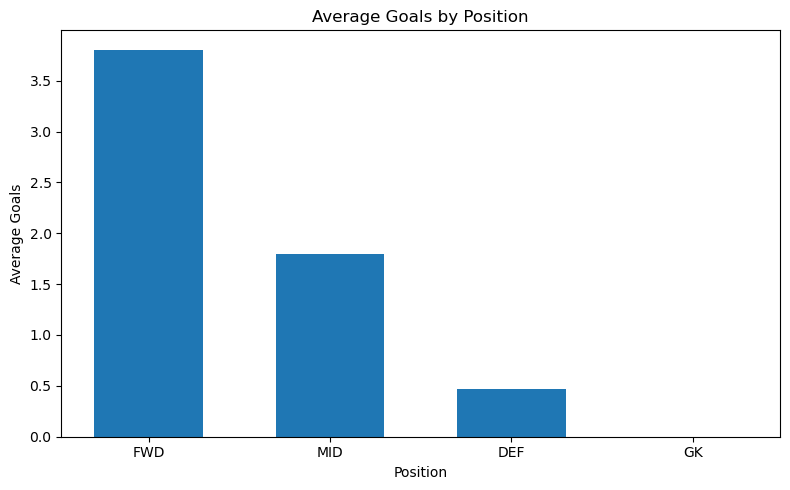

In [80]:
plt.figure(figsize=(8, 5))
plt.bar(pos_avg.index, pos_avg.values, width=0.6)
plt.title('Average Goals by Position')
plt.xlabel('Position')
plt.ylabel('Average Goals')
plt.tight_layout()
plt.show()

The bar chart tells you: on average, which position scores most.

But it hides everything else. Two positions could have the same average but completely different spreads. A few superstars could be pulling one group's average up while most players score nothing. The bar chart cannot show you that.

### Box plot

A box plot shows more than just the average. Let's look at the data first -- for each position, what does the spread of goals look like?

In [81]:
# Check the range for each position -- min, max, median
data.groupby('Position')['Goals'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Position,,,,,,,,
DEF,268.0,0.47,0.98,0.0,0.0,0.0,1.0,5.0
FWD,87.0,3.80,5.74,0.0,0.0,1.0,7.0,23.0
GK,82.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
MID,347.0,1.80,3.25,0.0,0.0,0.0,2.0,29.0


You can already see the spread is very different across positions. Forwards have a much higher max than goalkeepers. Now let's visualise that properly.

A box plot shows:
- The line in the middle: the median
- The box: where the middle 50% of players sit
- The lines extending out (whiskers): the range of typical values
- The dots beyond the whiskers: outliers -- the unusually high or low scorers

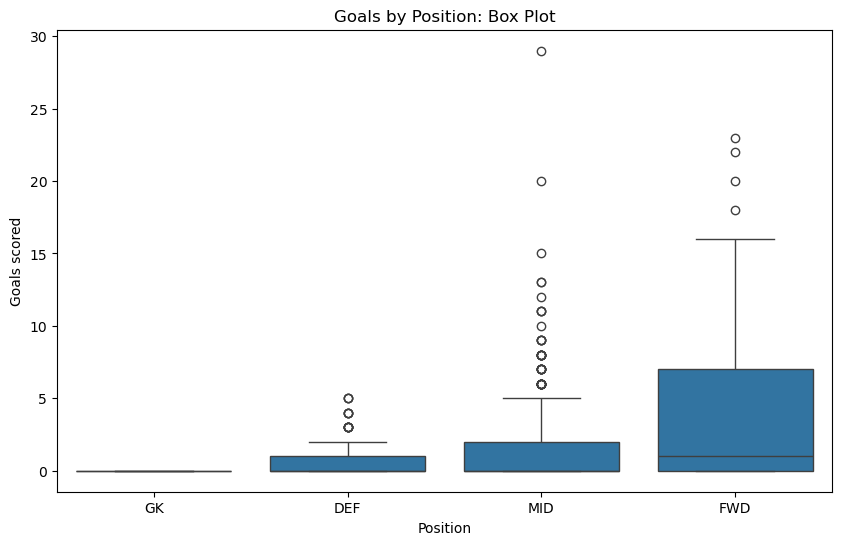

In [82]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Position', y='Goals', data=data, order=['GK', 'DEF', 'MID', 'FWD'])
plt.title('Goals by Position: Box Plot')
plt.xlabel('Position')
plt.ylabel('Goals scored')
plt.show()

Better. You can see the spread within each position. Forwards have a much wider box and longer whiskers than goalkeepers.

But you still cannot see where the data is dense. Are most forwards clustered around 5 goals with a few outliers at 20? Or is it spread evenly? The box plot cannot tell you that.

### Violin plot

A violin plot takes the box plot and adds a density layer. The width of the shape at any point shows how many players have values around there. Wide means lots of players. Narrow means very few.

Let's look at what the data looks like for forwards specifically before we plot:

In [83]:
# Distribution of goals for forwards
fwd_goals = data[data['Position'] == 'FWD']['Goals']

print(f"Min:    {fwd_goals.min()}")
print(f"Max:    {fwd_goals.max()}")
print(f"Median: {fwd_goals.median()}")
print(f"Mean:   {fwd_goals.mean():.2f}")
print()
print("How many forwards scored each amount:")
print(fwd_goals.value_counts().sort_index().head(10))

Min:    0
Max:    23
Median: 1.0
Mean:   3.80

How many forwards scored each amount:
Goals
0     43
1      8
2      3
3      6
4      3
5      1
7      2
8      2
9      4
10     5
Name: count, dtype: int64


Most forwards scored 0 goals. A handful scored a lot. That is exactly the kind of shape a violin plot will show well.

Now let's plot all positions:

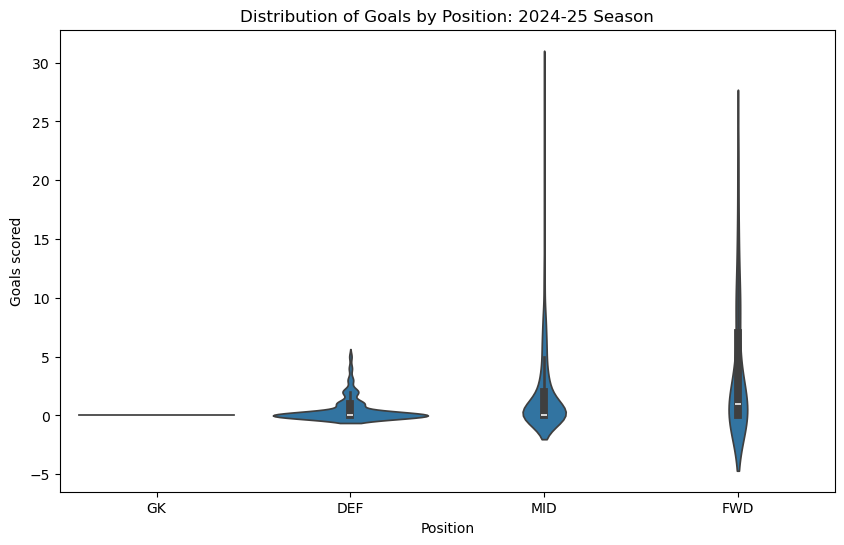

In [84]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Position', y='Goals', data=data, order=['GK', 'DEF', 'MID', 'FWD'])
plt.title('Distribution of Goals by Position: 2024-25 Season')
plt.xlabel('Position')
plt.ylabel('Goals scored')
plt.show()

Now you can see the full picture:
- The wide base of each violin shows where most players cluster -- near zero for every position
- The thin tail at the top shows the rare high scorers
- Forwards have the longest tail -- the biggest outliers come from that position
- Midfielders have a surprisingly wide body -- more midfielders score than you might expect

A few things to watch out for with any chart:
- `x` should be the groups (categories), `y` should be the numeric value -- swapping them produces a chart that makes no sense
- Make sure you are using the right chart type for what you are trying to show
- A bar chart, a box plot, and a violin plot can all use the same data but tell very different stories

## Step 11: Is the difference real?

The recruitment team is debating: do forwards genuinely outscore midfielders, or does it just look that way because of a few big names?

You could compare averages. But averages can be misleading. A few outliers like Salah or Haaland could pull one group's average up while most players in that group score very little. How do we know if the difference is real?

### The question a t-test answers

A t-test asks: how confident are we that the difference between two groups is real and not just a fluke of this particular season's data?

Let's think about it with a simple example first. Say you have two small groups:

- Group A: forwards from your local Sunday league: [2, 3, 2, 4, 3]
- Group B: midfielders from the same league: [1, 2, 1, 2, 1]

Group A averages 2.8, Group B averages 1.4. There is a difference. But is it real, or would it disappear if you watched different games?

### The t-statistic

The t-statistic measures how big the difference is relative to the natural variation within each group.

Think of it this way:
- Forwards average 5 goals, midfielders average 3. Difference of 2.
- But if forwards' individual tallies are all over the place -- some score 0, some score 20 -- that 2 goal difference does not mean much.
- If almost every forward scores between 4 and 6, then a 2 goal difference is significant.

So the t-statistic is roughly: difference between the two means divided by the spread within each group.

Big t-statistic: the difference is large relative to the noise. Likely real.
Small t-statistic: the difference could easily be noise.

### The p-value

The p-value converts the t-statistic into a probability. Specifically: what is the probability of seeing a difference this large if there were actually no real difference between the two groups?

- Small p-value (below 0.05): the difference is unlikely to be a fluke. We call it statistically significant.
- Large p-value (above 0.05): we cannot rule out that this is just noise.

The 0.05 threshold is a convention, not a law. It means: we are willing to accept a 5% chance of being wrong.

Let's see it in code with a simple made-up example first:

In [85]:
from scipy import stats

# Two made-up groups -- clear difference
group_a = [12, 15, 14, 13, 16, 14, 15]
group_b = [4, 5, 4, 6, 5, 4, 5]

t, p = stats.ttest_ind(group_a, group_b)
print(f"T-statistic: {t:.3f}")
print(f"P-value:     {p:.6f}")

if p < 0.05:
    print("The difference is statistically significant.")
else:
    print("Cannot conclude the groups are different.")

T-statistic: 16.167
P-value:     0.000000
The difference is statistically significant.


That p-value will be tiny because the two groups are clearly different. Now let's try with two groups that are more similar:

In [86]:
# Two groups that are close
group_c = [10, 11, 9, 10, 11]
group_d = [9, 10, 10, 11, 9]

t2, p2 = stats.ttest_ind(group_c, group_d)
print(f"T-statistic: {t2:.3f}")
print(f"P-value:     {p2:.4f}")

if p2 < 0.05:
    print("The difference is statistically significant.")
else:
    print("Cannot conclude the groups are different.")

T-statistic: 0.756
P-value:     0.4714
Cannot conclude the groups are different.


Now the p-value is large because the groups overlap so much. Now let's answer the real question:

In [87]:
fwd_goals = data[data['Position'] == 'FWD']['Goals']
mid_goals  = data[data['Position'] == 'MID']['Goals']

print(f"Forward average goals:   {fwd_goals.mean():.2f}")
print(f"Midfielder average goals: {mid_goals.mean():.2f}")
print()

t_stat, p_value = stats.ttest_ind(fwd_goals, mid_goals)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value:     {p_value:.4f}")
print()

if p_value < 0.05:
    print("Yes: forwards score significantly more than midfielders.")
else:
    print("No significant difference at the 0.05 level.")

Forward average goals:   3.80
Midfielder average goals: 1.80

T-statistic: 4.321
P-value:     0.0000

Yes: forwards score significantly more than midfielders.
